<a href="https://www.kaggle.com/code/omborse771924/global-tech-ai-startups-analysis?scriptVersionId=339757210" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv')

In [3]:
df.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [4]:
df.tail()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
24995,00571113,SpaceTech,2020,USA,Austin,Series B,21.00,86.55,3.96,1.20,16.2,111,43,68,Tier 3 (Angel/Seed),High,Independent
24996,AFA8F35C,Cybersecurity,2017,UK,Oxford,Series B,29.38,316.21,16.36,3.11,9.2,214,99,115,Tier 2 (Mid-size VC),High,Independent
24997,0EEEA516,Web3/Crypto,2021,Singapore,Singapore,Series B,7.84,57.81,3.79,0.31,19.1,29,0,29,Tier 3 (Angel/Seed),High,Independent
24998,586B1BAF,ClimateTech,2020,Singapore,Singapore,Series A,0.00,33.67,1.96,0.45,0.0,41,0,41,Bootstrapped,High,Independent
24999,DC703A98,Web3/Crypto,2022,USA,Boston,Series A,6.15,70.04,3.96,0.65,8.2,40,29,11,Tier 3 (Angel/Seed),High,Closed


In [5]:
df.info

<bound method DataFrame.info of       Company_ID         Domain  Founding_Year    Country           City  \
0       B730AD52     HealthTech           2014     Canada       Montreal   
1       65A5F690    Web3/Crypto           2014      China        Beijing   
2       F106C853  Cybersecurity           2020        USA  San Francisco   
3       2BD798AF        FinTech           2023      India      Delhi NCR   
4       C5CB4451  Generative AI           2020        USA       New York   
...          ...            ...            ...        ...            ...   
24995   00571113      SpaceTech           2020        USA         Austin   
24996   AFA8F35C  Cybersecurity           2017         UK         Oxford   
24997   0EEEA516    Web3/Crypto           2021  Singapore      Singapore   
24998   586B1BAF    ClimateTech           2020  Singapore      Singapore   
24999   DC703A98    Web3/Crypto           2022        USA         Boston   

      Funding_Stage  Total_Funding_USD_Millions  Valuat

In [6]:
df.describe

<bound method NDFrame.describe of       Company_ID         Domain  Founding_Year    Country           City  \
0       B730AD52     HealthTech           2014     Canada       Montreal   
1       65A5F690    Web3/Crypto           2014      China        Beijing   
2       F106C853  Cybersecurity           2020        USA  San Francisco   
3       2BD798AF        FinTech           2023      India      Delhi NCR   
4       C5CB4451  Generative AI           2020        USA       New York   
...          ...            ...            ...        ...            ...   
24995   00571113      SpaceTech           2020        USA         Austin   
24996   AFA8F35C  Cybersecurity           2017         UK         Oxford   
24997   0EEEA516    Web3/Crypto           2021  Singapore      Singapore   
24998   586B1BAF    ClimateTech           2020  Singapore      Singapore   
24999   DC703A98    Web3/Crypto           2022        USA         Boston   

      Funding_Stage  Total_Funding_USD_Millions  Valu

In [7]:
df.isnull

<bound method DataFrame.isnull of       Company_ID         Domain  Founding_Year    Country           City  \
0       B730AD52     HealthTech           2014     Canada       Montreal   
1       65A5F690    Web3/Crypto           2014      China        Beijing   
2       F106C853  Cybersecurity           2020        USA  San Francisco   
3       2BD798AF        FinTech           2023      India      Delhi NCR   
4       C5CB4451  Generative AI           2020        USA       New York   
...          ...            ...            ...        ...            ...   
24995   00571113      SpaceTech           2020        USA         Austin   
24996   AFA8F35C  Cybersecurity           2017         UK         Oxford   
24997   0EEEA516    Web3/Crypto           2021  Singapore      Singapore   
24998   586B1BAF    ClimateTech           2020  Singapore      Singapore   
24999   DC703A98    Web3/Crypto           2022        USA         Boston   

      Funding_Stage  Total_Funding_USD_Millions  Valu

In [8]:
df.isnull().sum()

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64

In [9]:
# Check missing values
print(df.isnull().sum())

# Fill categorical null values with mode
df["AI_Adoption_Level"] = df["AI_Adoption_Level"].fillna(
    df["AI_Adoption_Level"].mode()[0]
)

# Verify
print(df.isnull().sum())

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64
Company_ID                    0
Domain                        0
Founding_Year                 0
Country                       0
City                          0
Funding_Stage                 0
Total_Funding_USD_Millions    0
Valuation_USD_Millions        0
Revenue_ARR_Millions          0
Monthly_Burn_Rate_Millions    0
Runway_Months_2024            0
Peak_Headcount_2023           0
Layoffs_

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Company_ID', 'Domain', 'Founding_Year', 'Country', 'City',
       'Funding_Stage', 'Total_Funding_USD_Millions', 'Valuation_USD_Millions',
       'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions',
       'Runway_Months_2024', 'Peak_Headcount_2023', 'Layoffs_2024_2025',
       'Current_Headcount_2026', 'Investor_Tier', 'AI_Adoption_Level',
       'Acquisition_Status'],
      dtype='object')

## EDA

  Company_ID         Domain  Founding_Year Country           City  \
0   B730AD52     HealthTech           2014  Canada       Montreal   
1   65A5F690    Web3/Crypto           2014   China        Beijing   
2   F106C853  Cybersecurity           2020     USA  San Francisco   
3   2BD798AF        FinTech           2023   India      Delhi NCR   
4   C5CB4451  Generative AI           2020     USA       New York   

  Funding_Stage  Total_Funding_USD_Millions  Valuation_USD_Millions  \
0          Seed                        1.64                   17.81   
1       Pre-IPO                      103.87                  949.16   
2      Series A                       10.08                   43.37   
3      Series B                       32.28                  257.62   
4     Series C+                       13.41                   76.73   

   Revenue_ARR_Millions  Monthly_Burn_Rate_Millions  Runway_Months_2024  \
0                  1.46                        0.33                 3.8   
1       

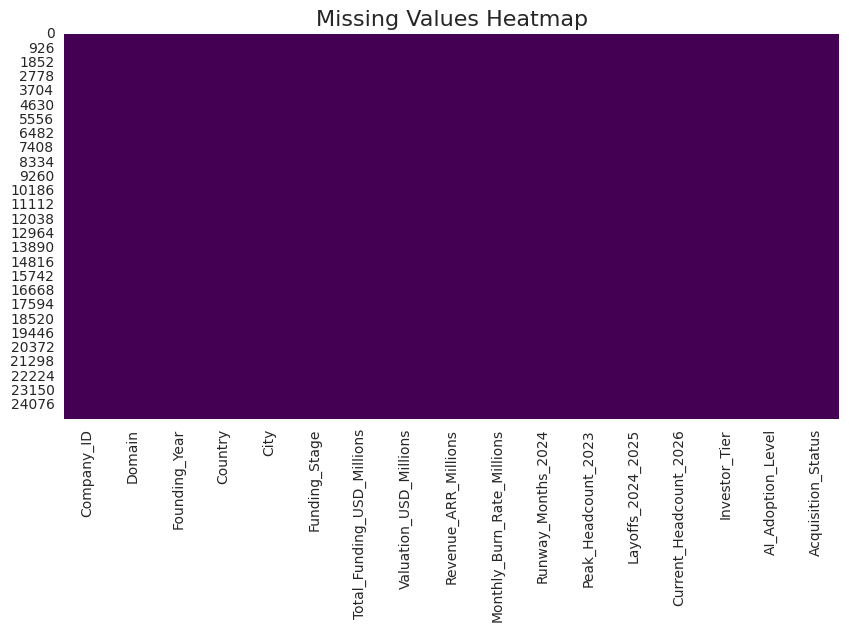

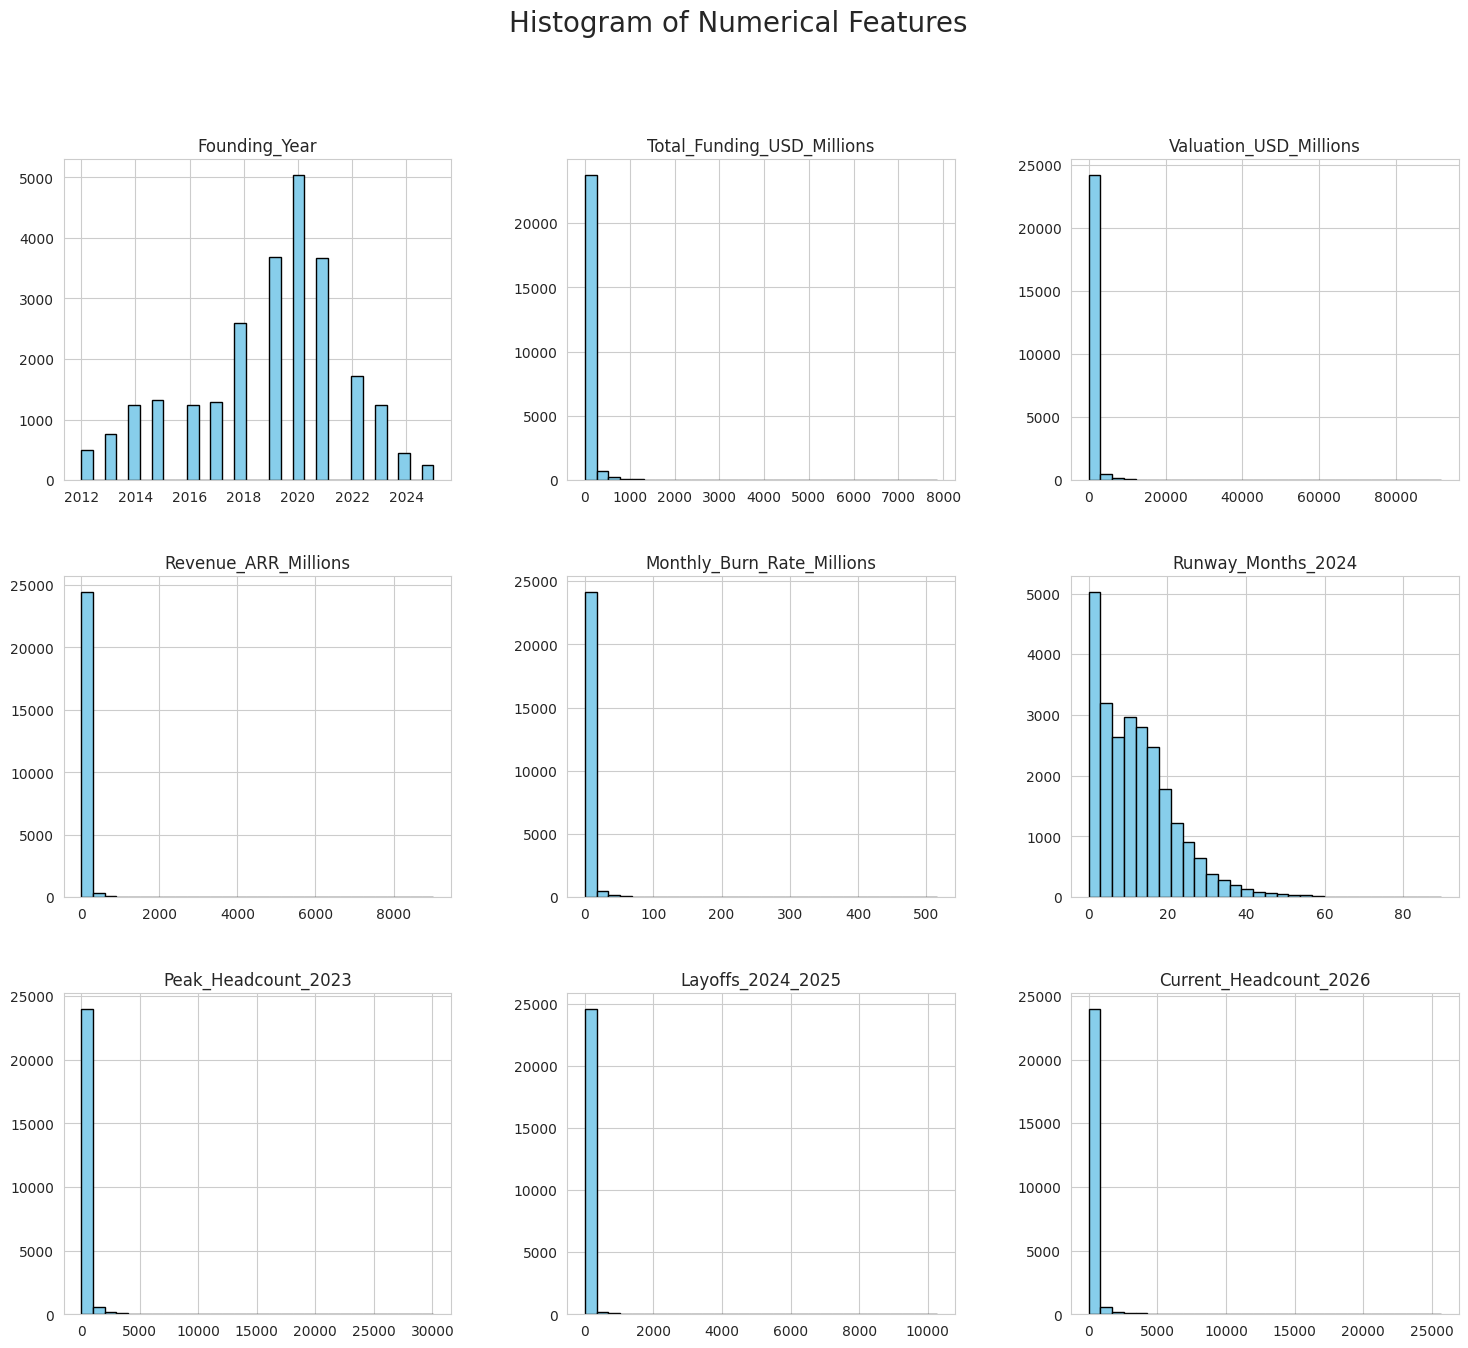

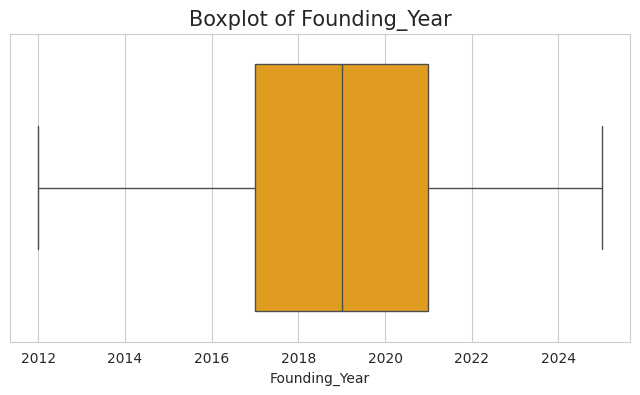

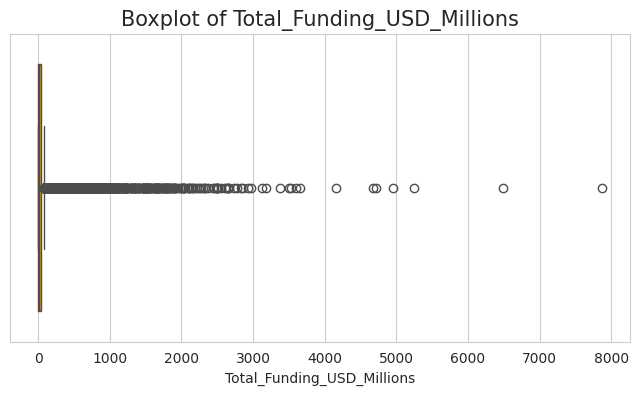

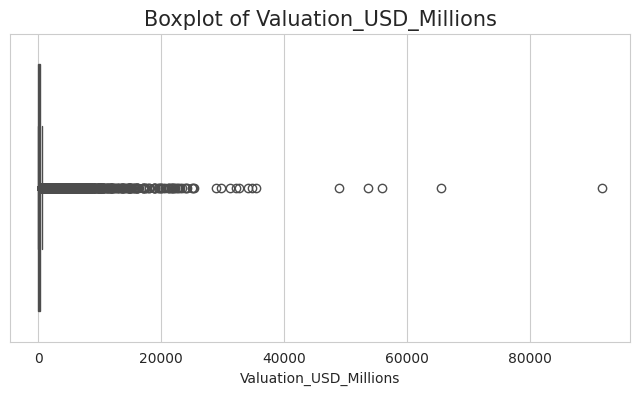

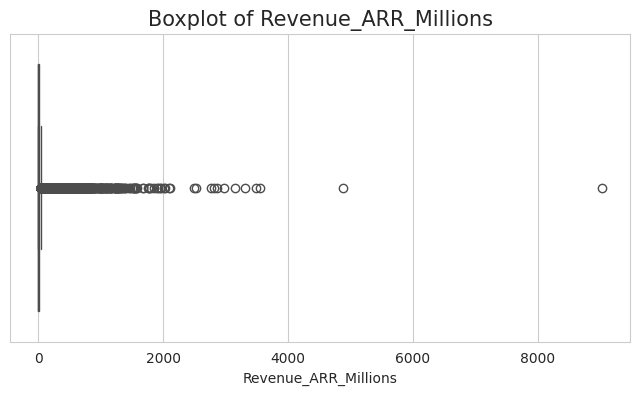

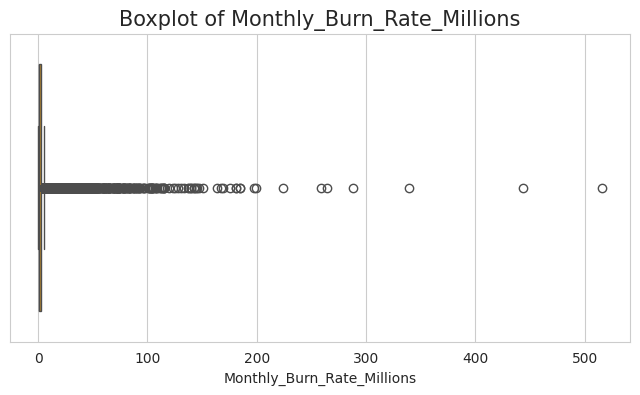

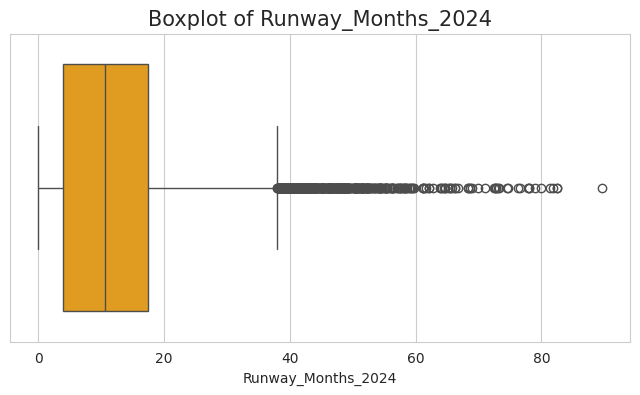

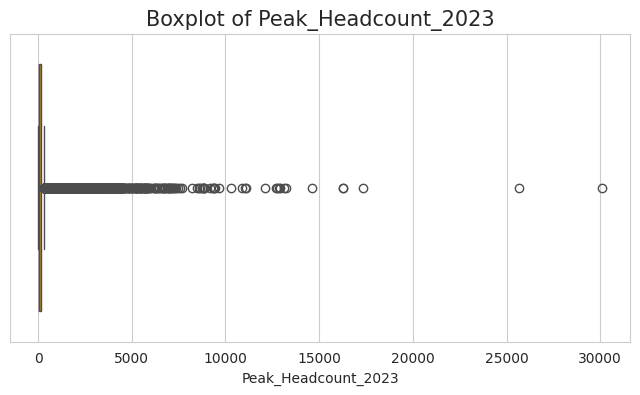

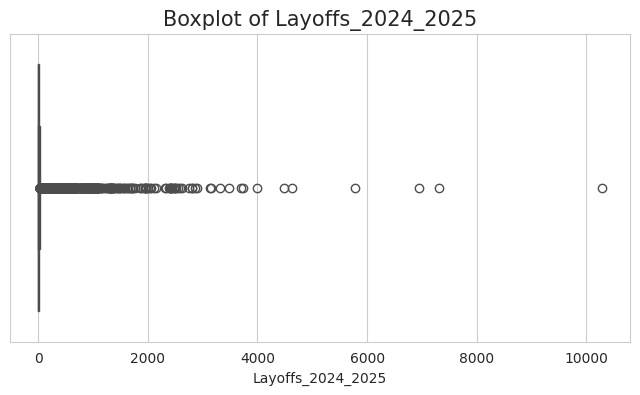

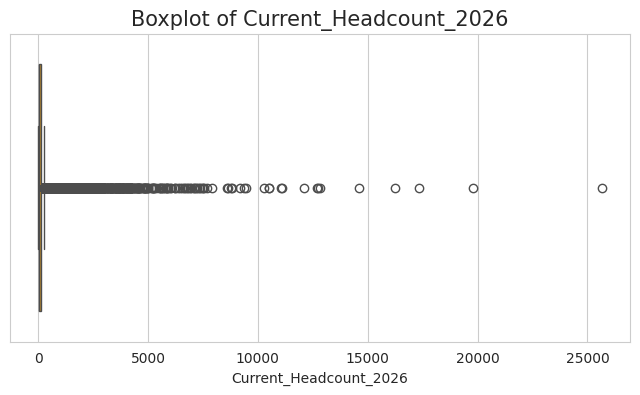

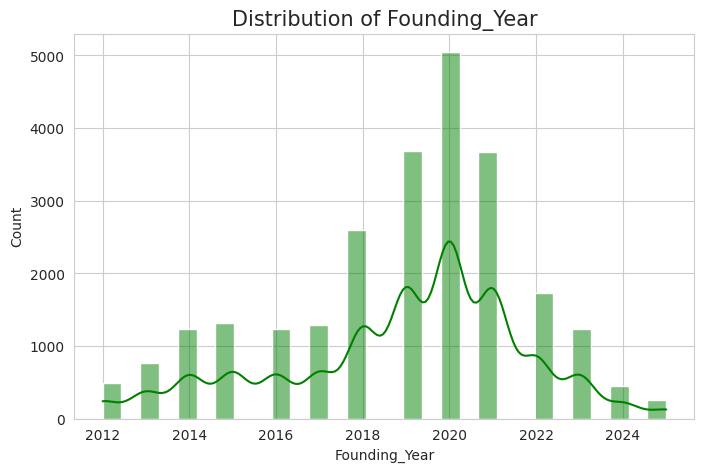

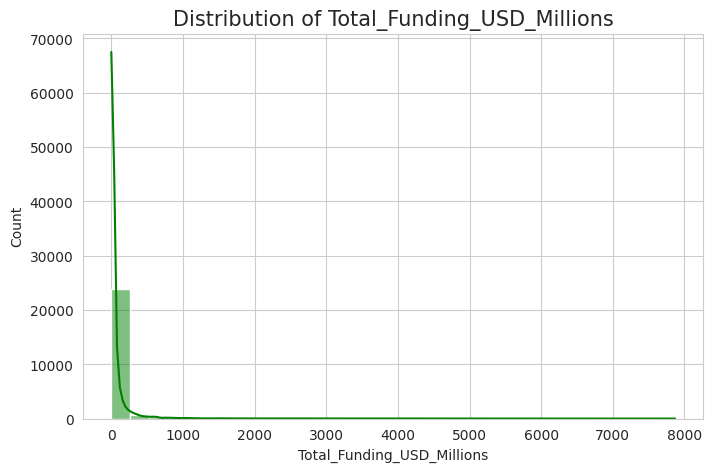

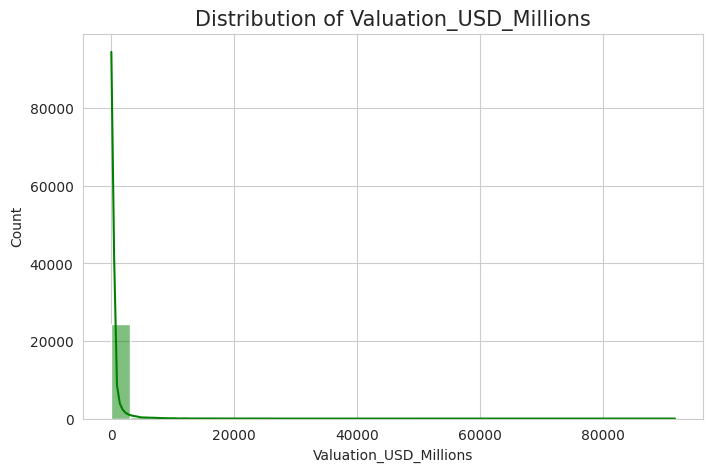

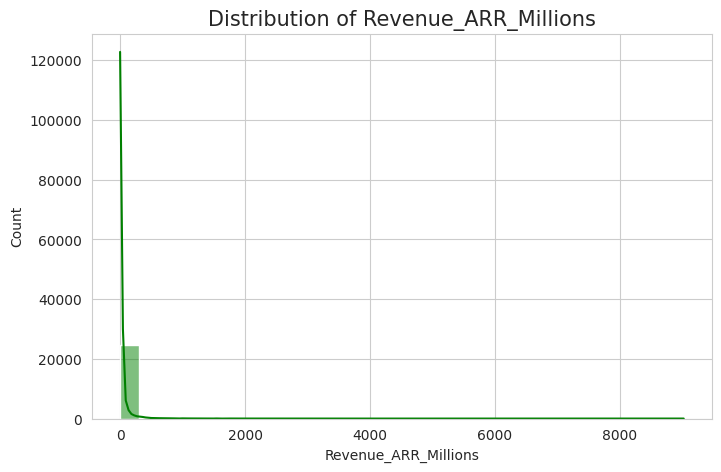

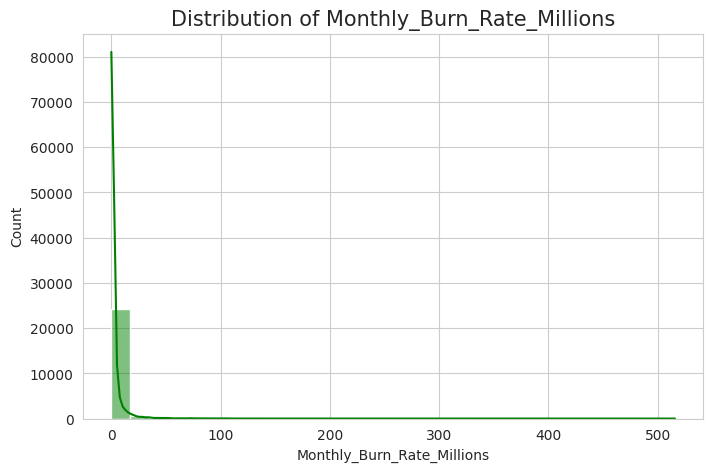

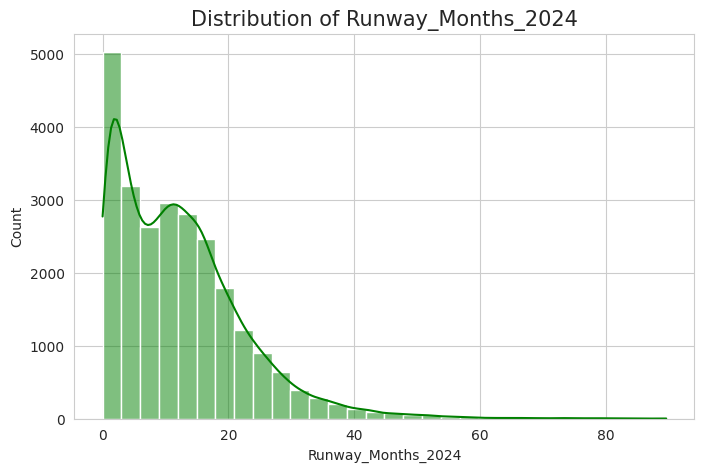

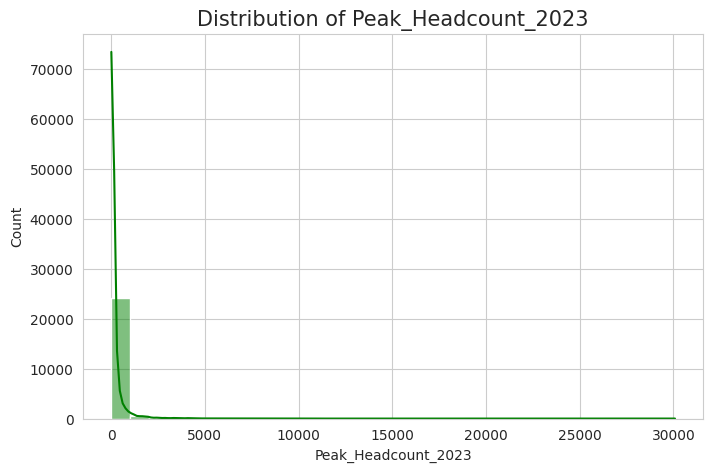

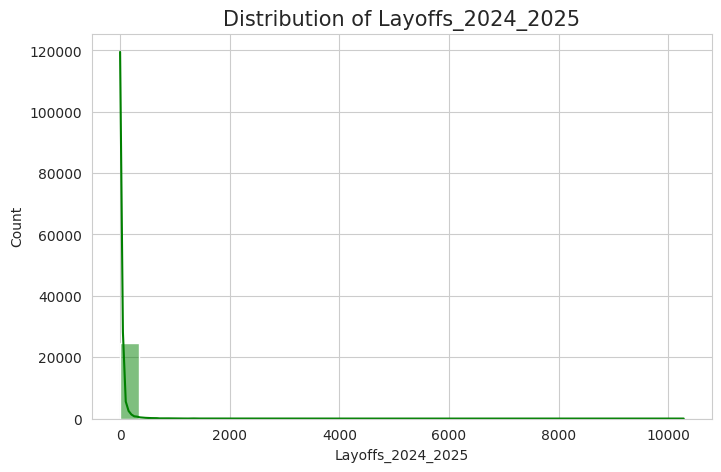

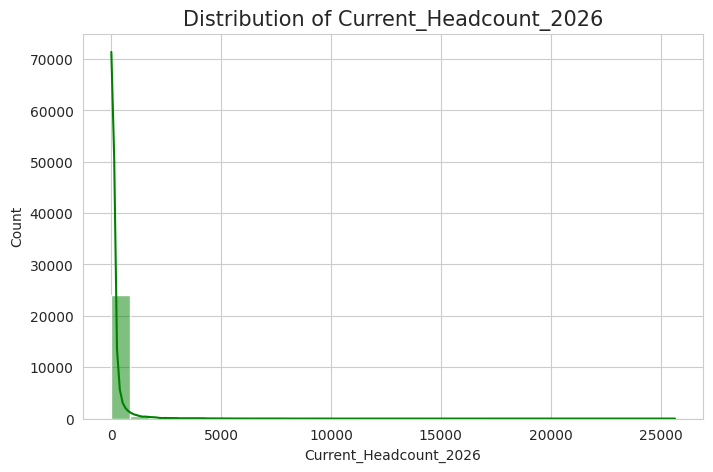

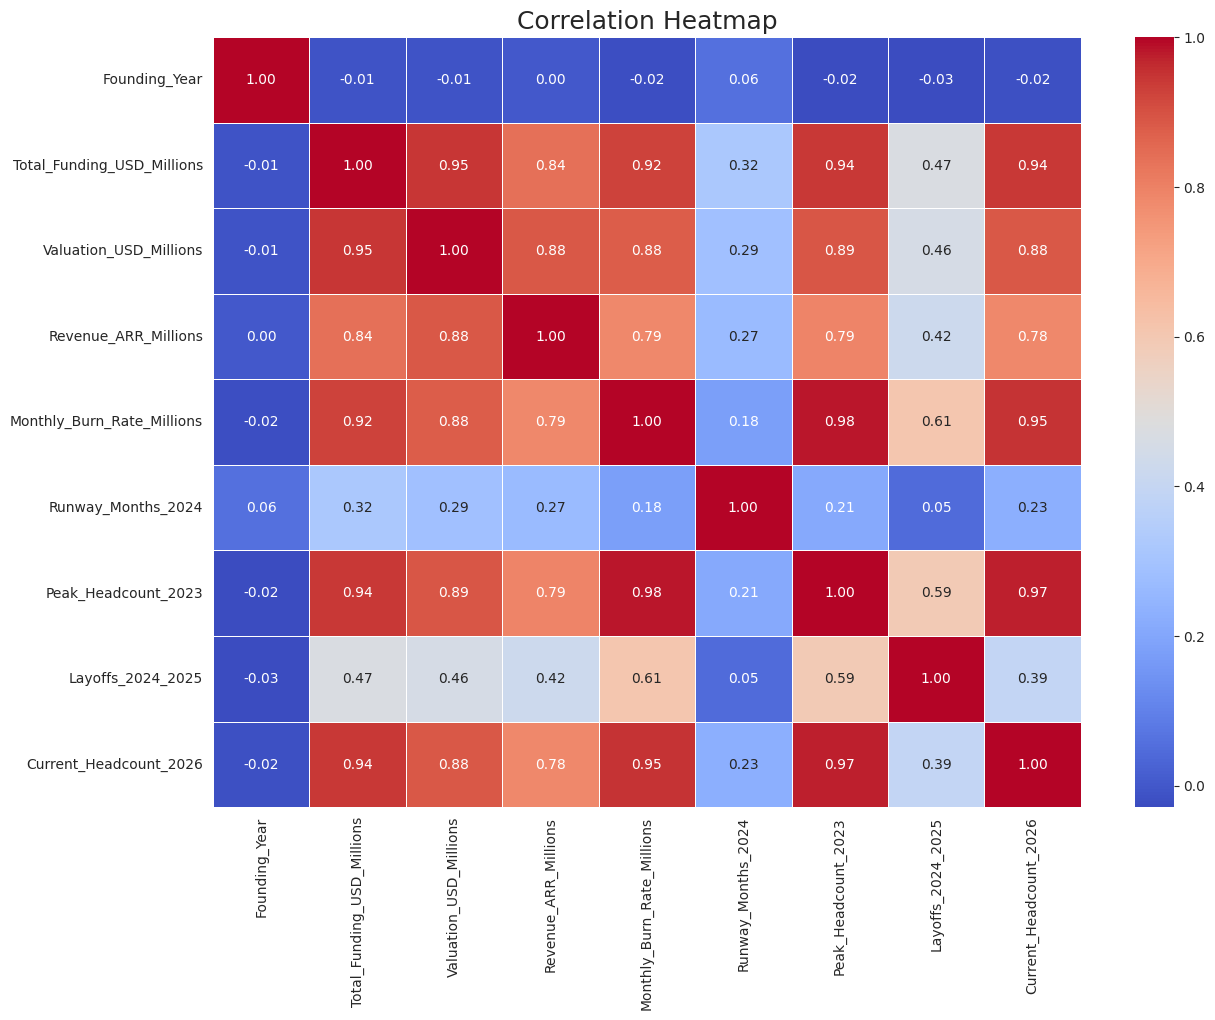

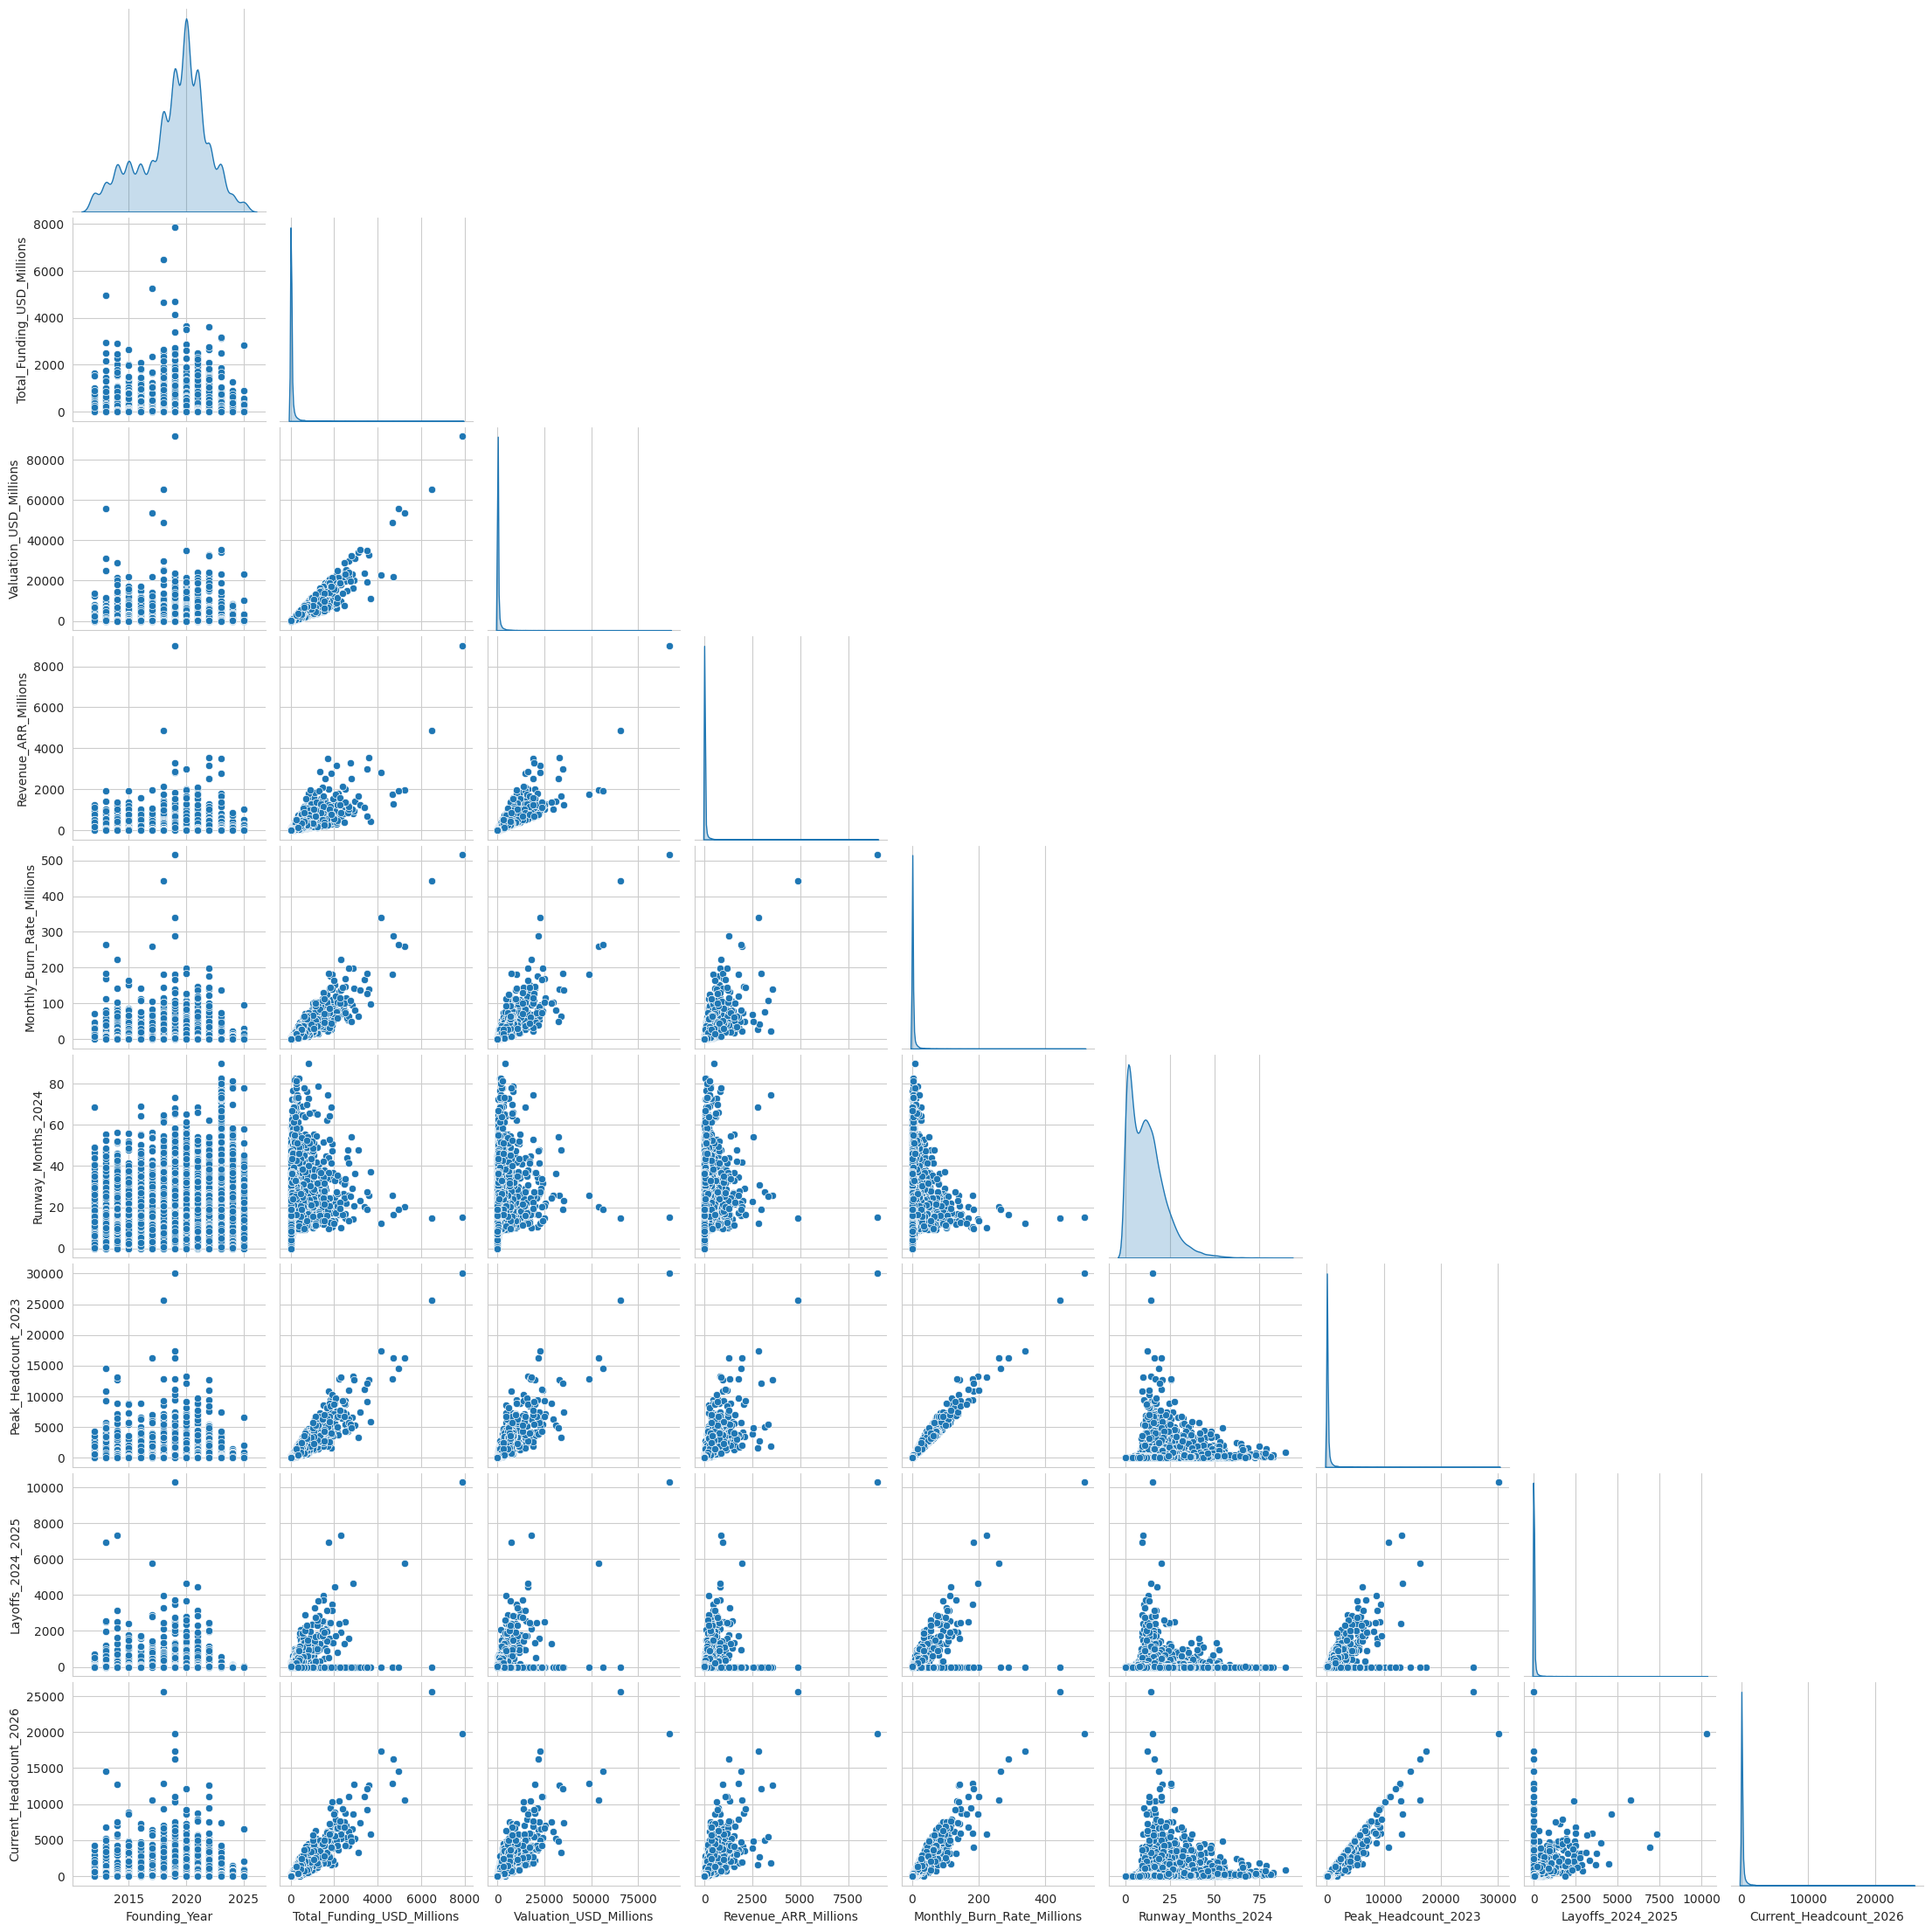

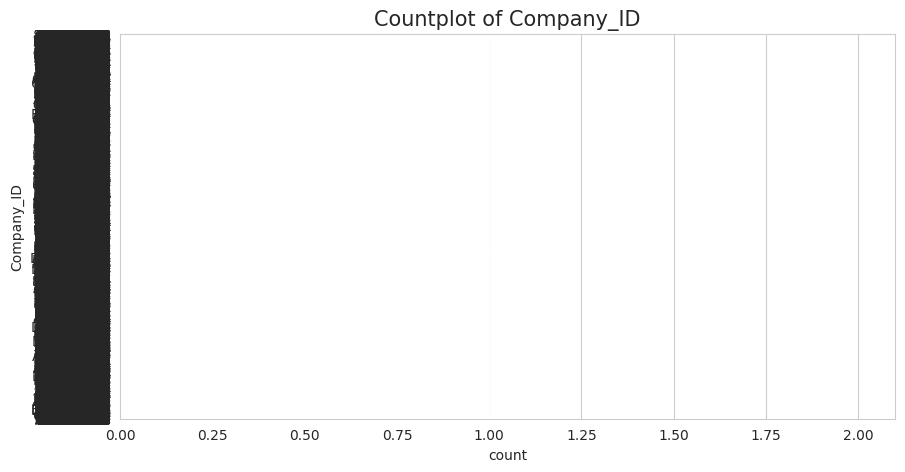

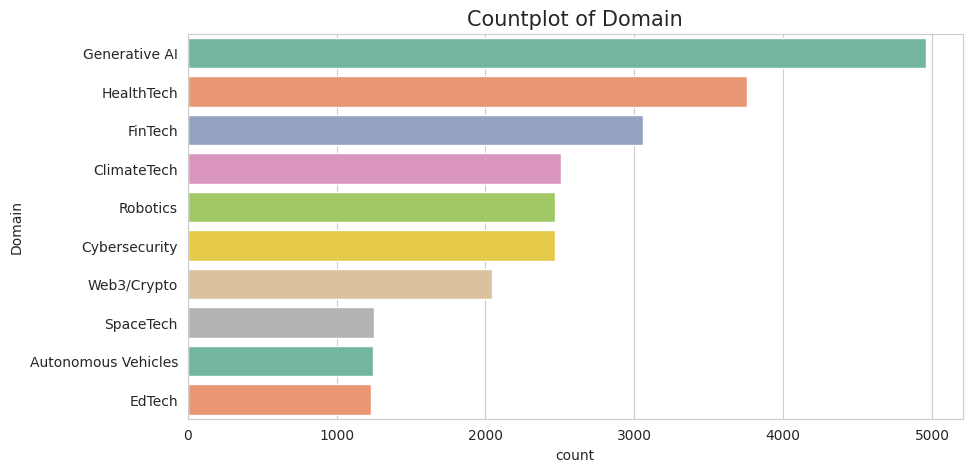

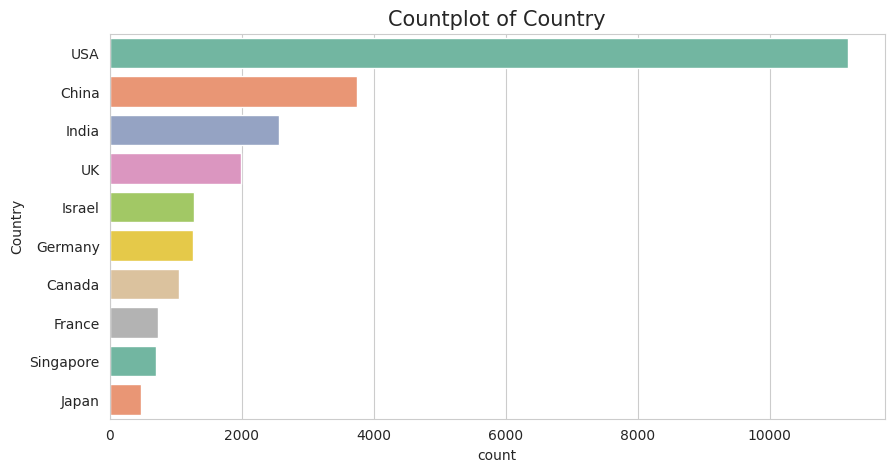

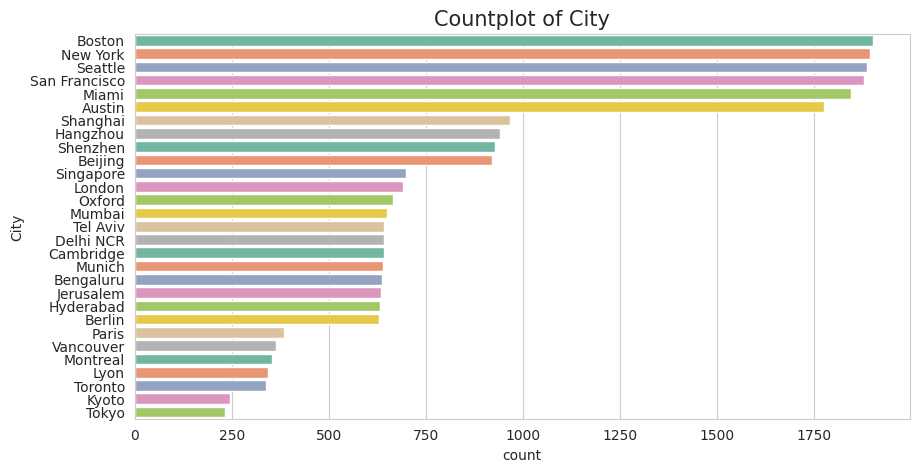

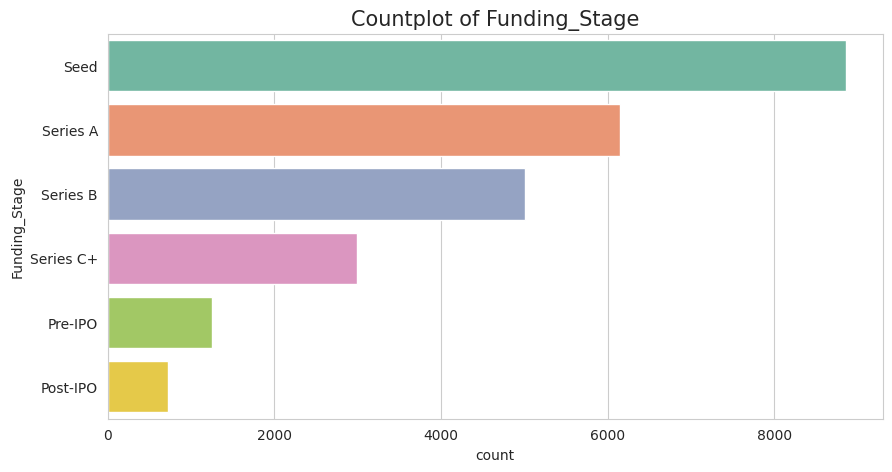

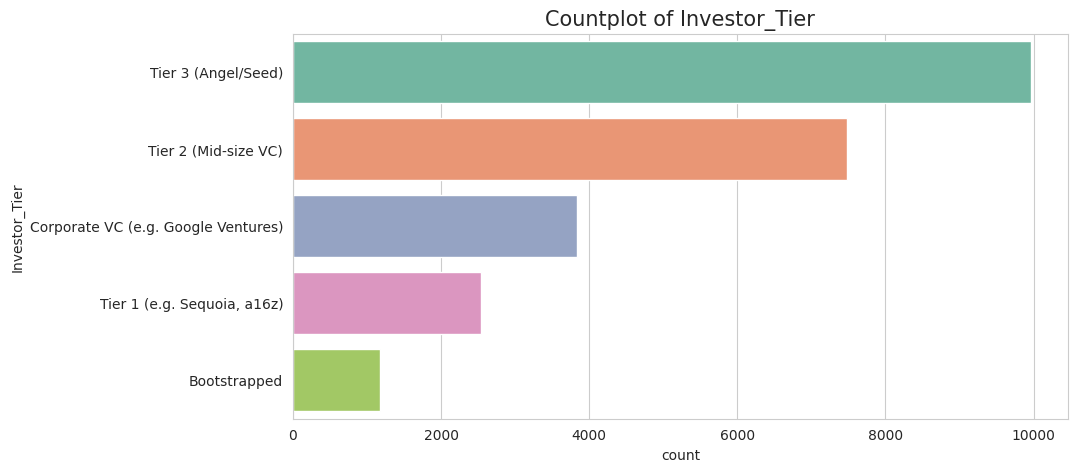

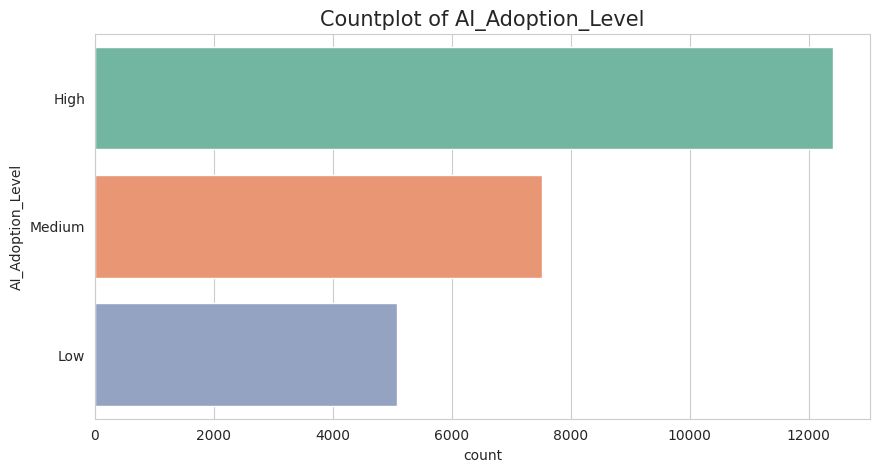

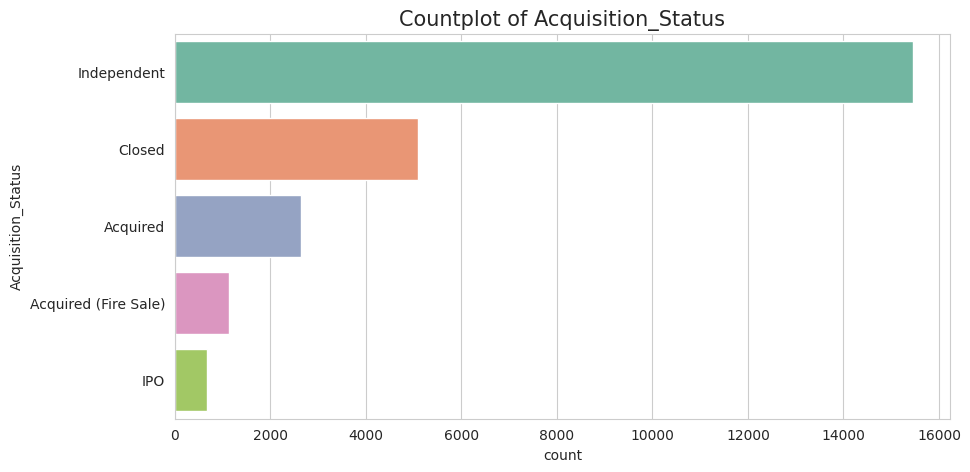

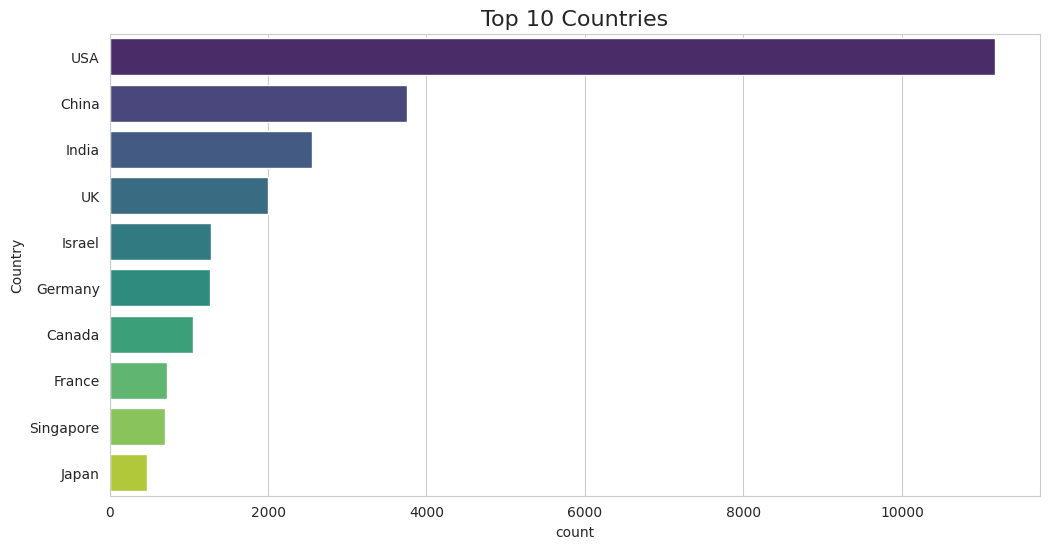

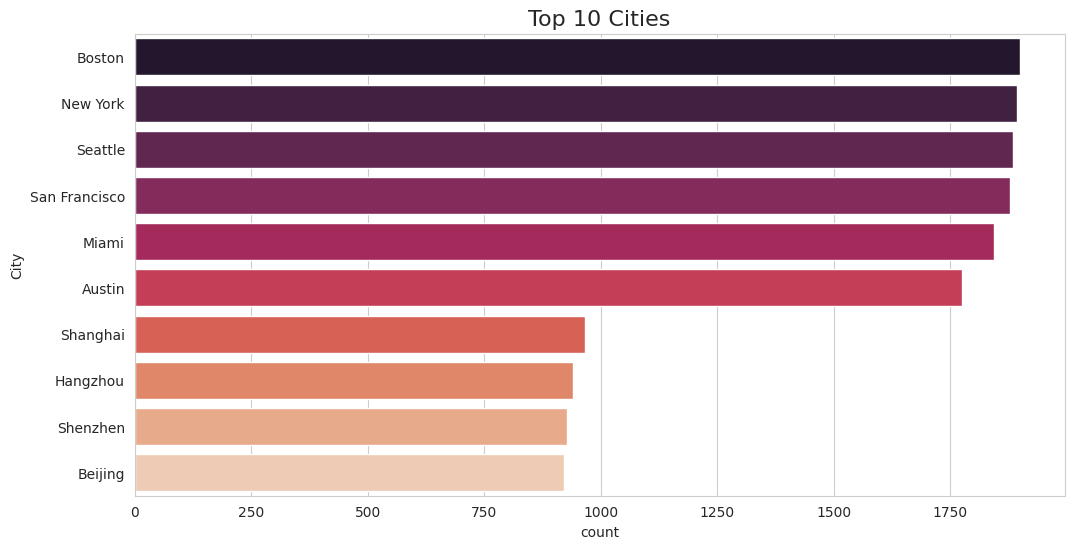

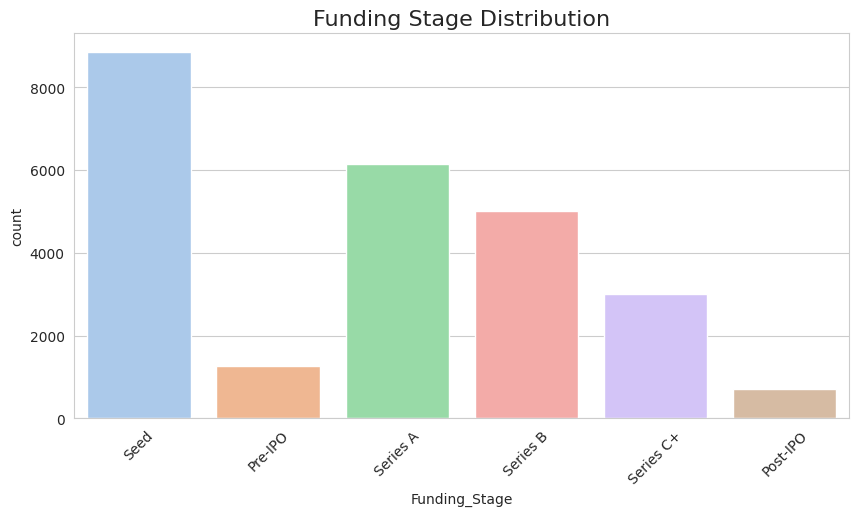

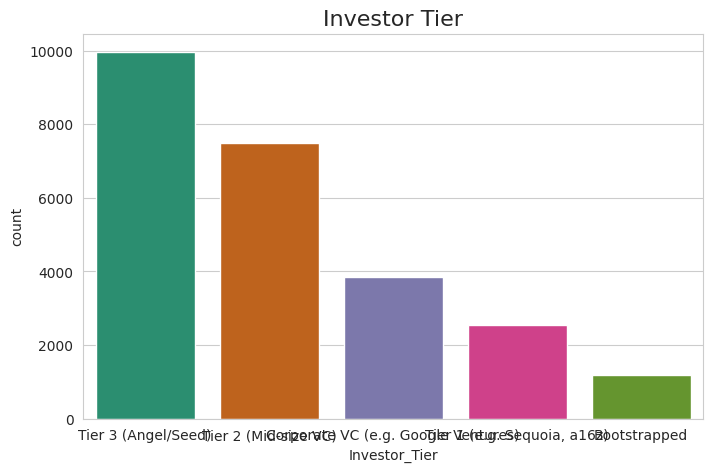

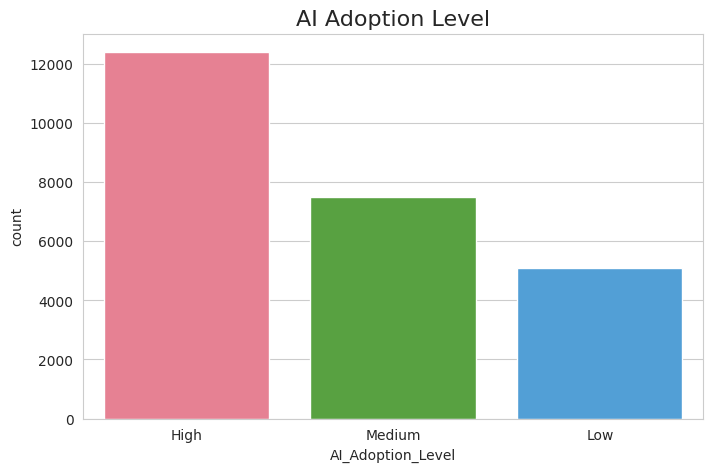

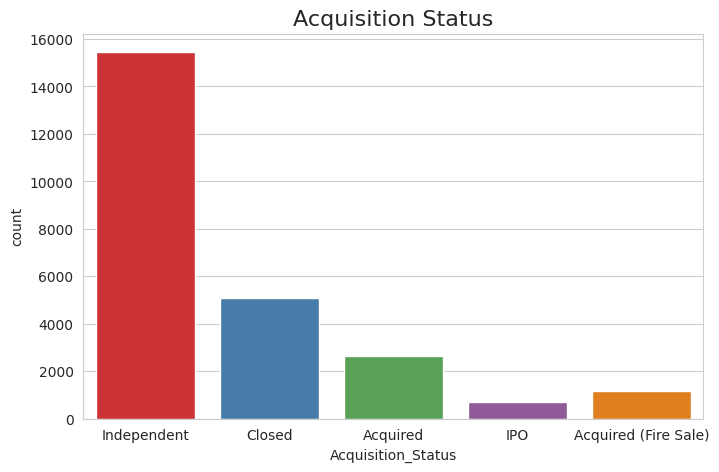

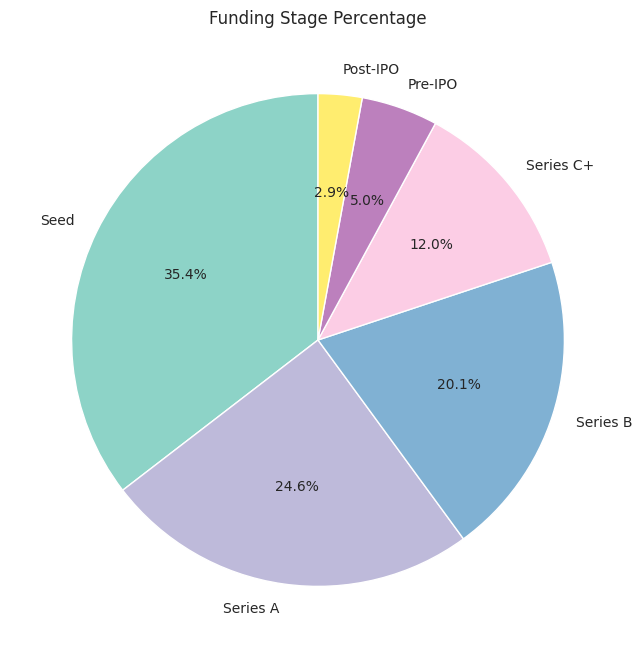

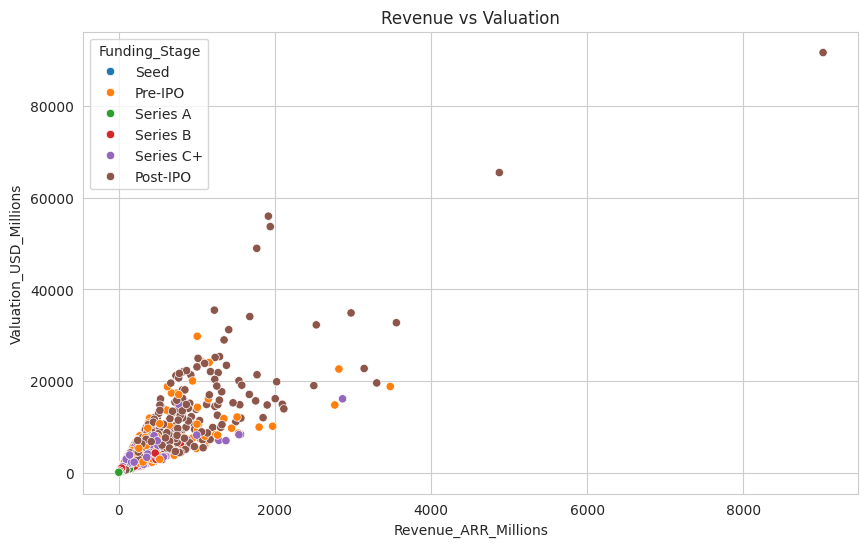

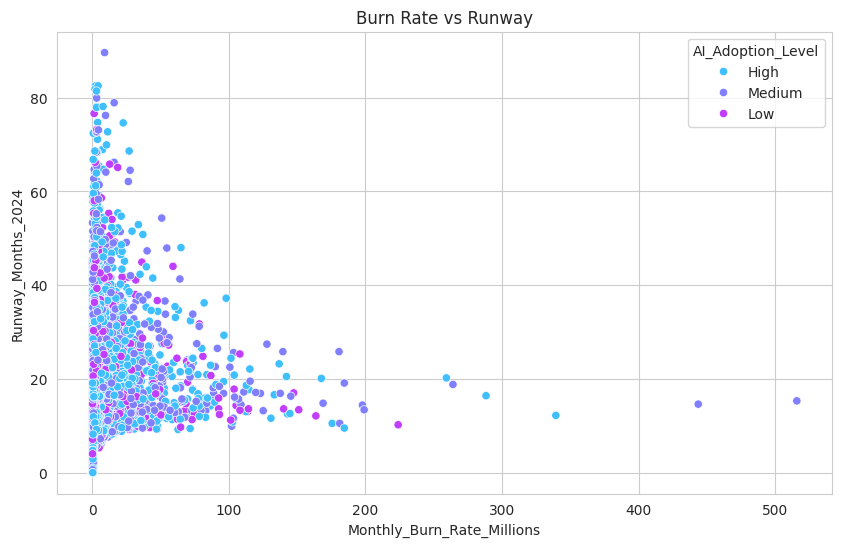

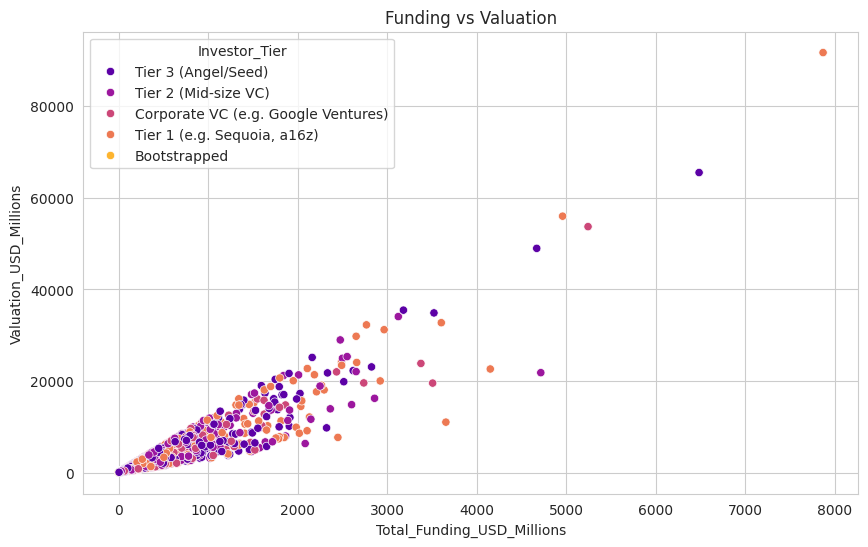

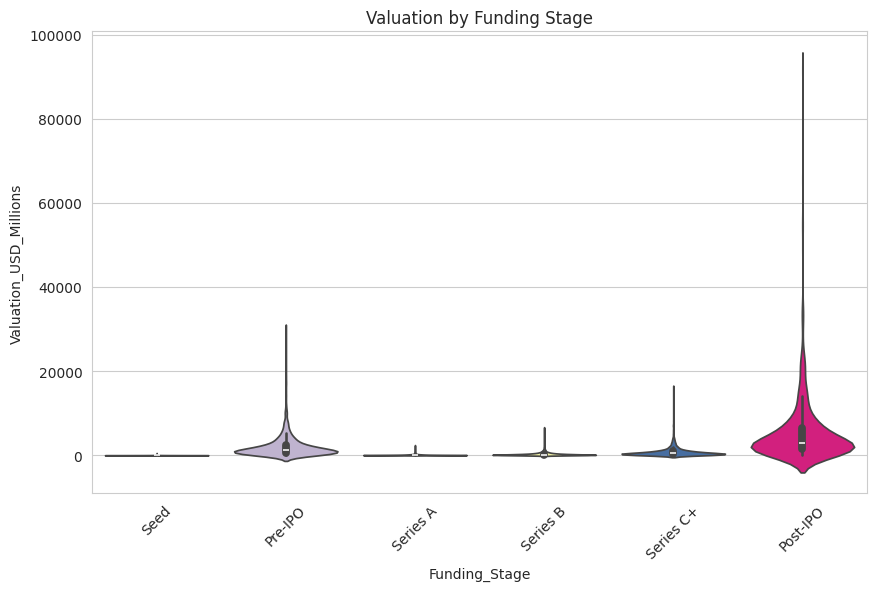

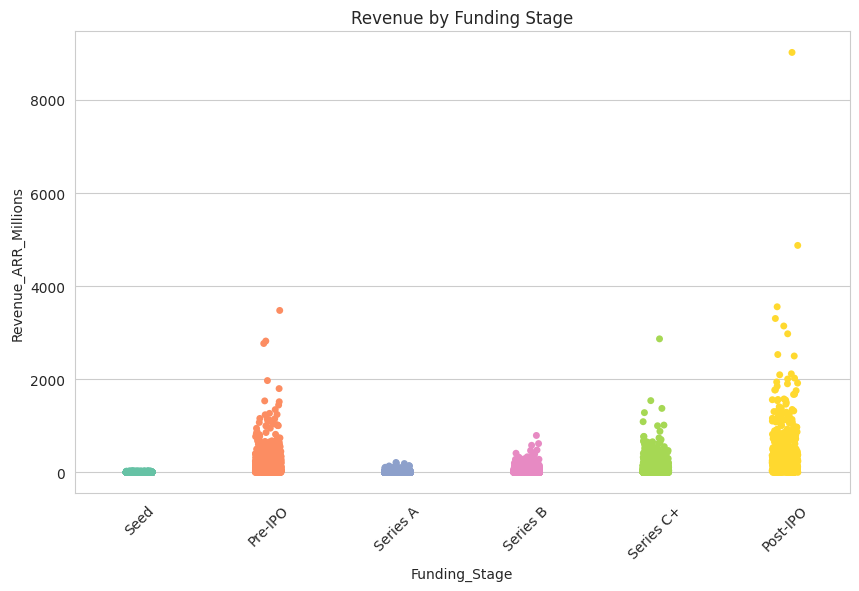

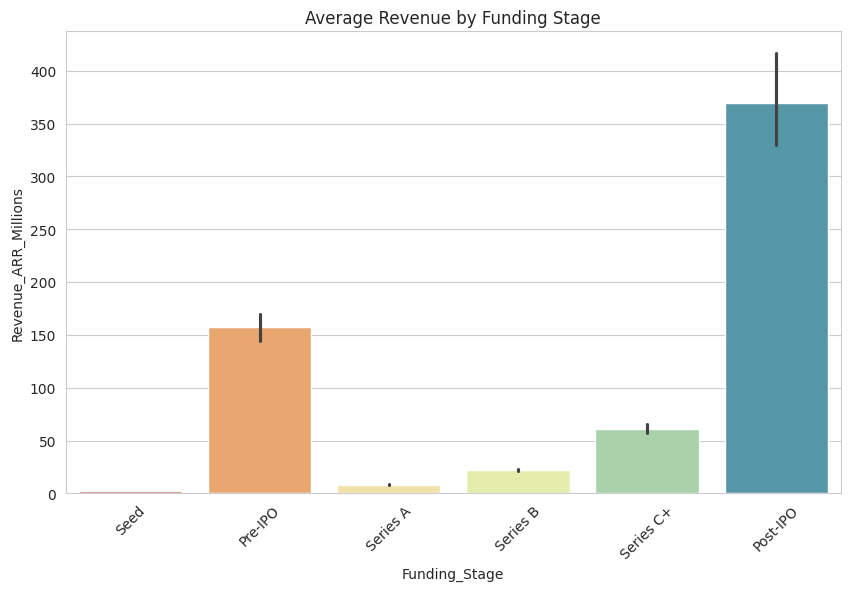

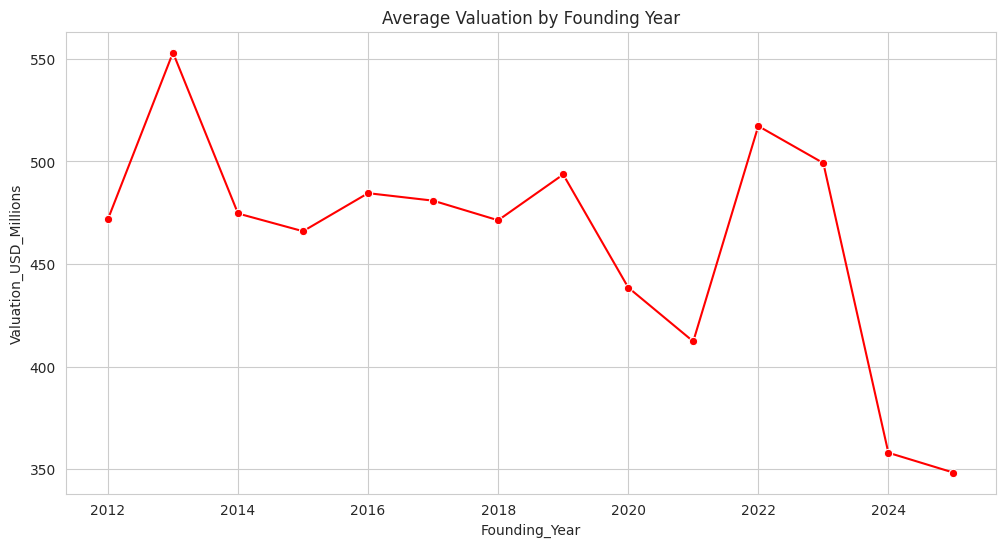

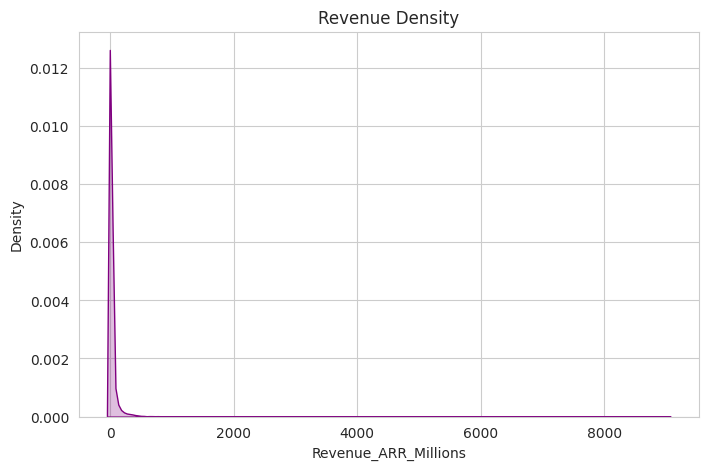

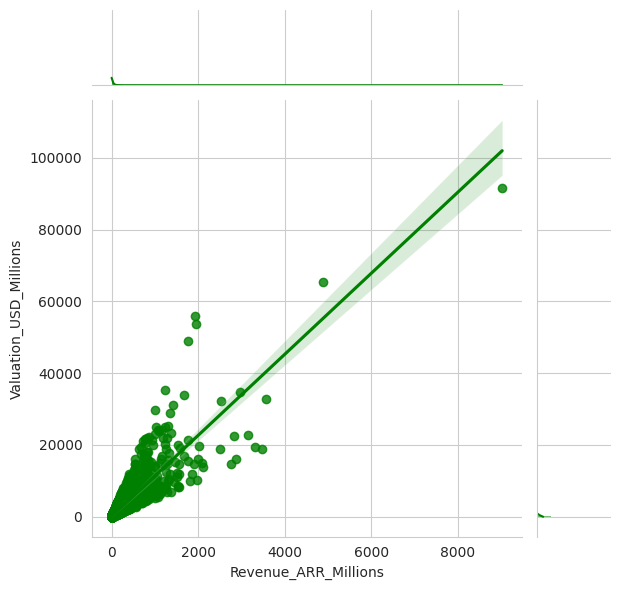

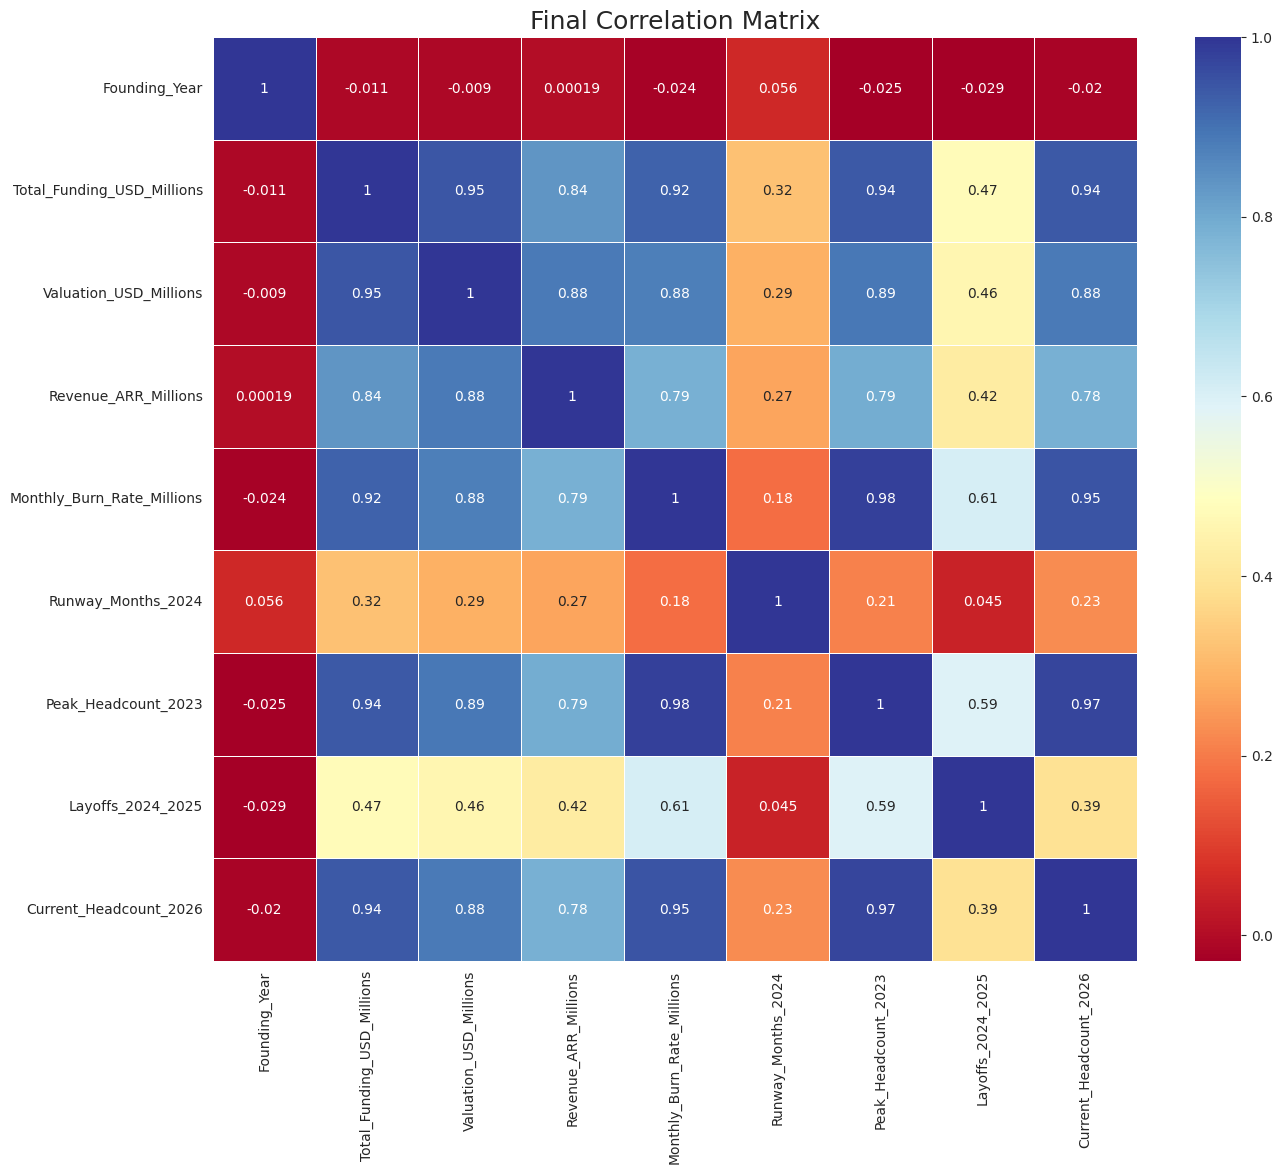

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Basic Settings
# -------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# -------------------------------
# Dataset Overview
# -------------------------------
print(df.head())
print(df.info())
print(df.describe(include='all'))

# -------------------------------
# Missing Values
# -------------------------------
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap",fontsize=16)
plt.show()

# -------------------------------
# Numeric & Categorical Columns
# -------------------------------
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

# -------------------------------
# Histograms
# -------------------------------
df[num_cols].hist(
    figsize=(18,15),
    bins=30,
    color="skyblue",
    edgecolor="black"
)
plt.suptitle("Histogram of Numerical Features",fontsize=20)
plt.show()

# -------------------------------
# Boxplots
# -------------------------------
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(
        x=df[col],
        color="orange"
    )
    plt.title(f"Boxplot of {col}",fontsize=15)
    plt.show()

# -------------------------------
# Distribution Plot
# -------------------------------
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color="green"
    )
    plt.title(f"Distribution of {col}",fontsize=15)
    plt.show()

# -------------------------------
# Correlation Heatmap
# -------------------------------
plt.figure(figsize=(14,10))
corr=df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap",fontsize=18)
plt.show()

# -------------------------------
# Pairplot
# -------------------------------
sns.pairplot(
    df[num_cols],
    diag_kind="kde",
    corner=True
)
plt.show()

# -------------------------------
# Countplots
# -------------------------------
colors=[
'red','blue','green','orange','purple',
'pink','cyan','gold','brown','magenta'
]

for i,col in enumerate(cat_cols):
    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index,
        palette="Set2"
    )

    plt.title(f"Countplot of {col}",fontsize=15)
    plt.show()

# -------------------------------
# Top Countries
# -------------------------------
plt.figure(figsize=(12,6))

sns.countplot(
    y="Country",
    data=df,
    order=df["Country"].value_counts().head(10).index,
    palette="viridis"
)

plt.title("Top 10 Countries",fontsize=16)
plt.show()

# -------------------------------
# Top Cities
# -------------------------------
plt.figure(figsize=(12,6))

sns.countplot(
    y="City",
    data=df,
    order=df["City"].value_counts().head(10).index,
    palette="rocket"
)

plt.title("Top 10 Cities",fontsize=16)
plt.show()

# -------------------------------
# Funding Stage
# -------------------------------
plt.figure(figsize=(10,5))

sns.countplot(
    x="Funding_Stage",
    data=df,
    palette="pastel"
)

plt.xticks(rotation=45)
plt.title("Funding Stage Distribution",fontsize=16)
plt.show()

# -------------------------------
# Investor Tier
# -------------------------------
plt.figure(figsize=(8,5))

sns.countplot(
    x="Investor_Tier",
    data=df,
    palette="Dark2"
)

plt.title("Investor Tier",fontsize=16)
plt.show()

# -------------------------------
# AI Adoption
# -------------------------------
plt.figure(figsize=(8,5))

sns.countplot(
    x="AI_Adoption_Level",
    data=df,
    palette="husl"
)

plt.title("AI Adoption Level",fontsize=16)
plt.show()

# -------------------------------
# Acquisition Status
# -------------------------------
plt.figure(figsize=(8,5))

sns.countplot(
    x="Acquisition_Status",
    data=df,
    palette="Set1"
)

plt.title("Acquisition Status",fontsize=16)
plt.show()

# -------------------------------
# Pie Chart
# -------------------------------
plt.figure(figsize=(8,8))

df["Funding_Stage"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    cmap="Set3"
)

plt.ylabel("")
plt.title("Funding Stage Percentage")
plt.show()

# -------------------------------
# Revenue vs Valuation
# -------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Revenue_ARR_Millions",
    y="Valuation_USD_Millions",
    hue="Funding_Stage",
    palette="tab10"
)

plt.title("Revenue vs Valuation")
plt.show()

# -------------------------------
# Burn Rate vs Runway
# -------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Monthly_Burn_Rate_Millions",
    y="Runway_Months_2024",
    hue="AI_Adoption_Level",
    palette="cool"
)

plt.title("Burn Rate vs Runway")
plt.show()

# -------------------------------
# Funding vs Valuation
# -------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Total_Funding_USD_Millions",
    y="Valuation_USD_Millions",
    hue="Investor_Tier",
    palette="plasma"
)

plt.title("Funding vs Valuation")
plt.show()

# -------------------------------
# Violin Plot
# -------------------------------
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Funding_Stage",
    y="Valuation_USD_Millions",
    palette="Accent"
)

plt.xticks(rotation=45)
plt.title("Valuation by Funding Stage")
plt.show()

# -------------------------------
# Strip Plot
# -------------------------------
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df,
    x="Funding_Stage",
    y="Revenue_ARR_Millions",
    palette="Set2",
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Revenue by Funding Stage")
plt.show()

# -------------------------------
# Barplot
# -------------------------------
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Funding_Stage",
    y="Revenue_ARR_Millions",
    estimator="mean",
    palette="Spectral"
)

plt.xticks(rotation=45)
plt.title("Average Revenue by Funding Stage")
plt.show()

# -------------------------------
# Line Plot
# -------------------------------
year=df.groupby("Founding_Year")["Valuation_USD_Millions"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year,
    x="Founding_Year",
    y="Valuation_USD_Millions",
    marker="o",
    color="red"
)

plt.title("Average Valuation by Founding Year")
plt.show()

# -------------------------------
# KDE Plot
# -------------------------------
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Revenue_ARR_Millions",
    fill=True,
    color="purple"
)

plt.title("Revenue Density")
plt.show()

# -------------------------------
# Joint Plot
# -------------------------------
sns.jointplot(
    data=df,
    x="Revenue_ARR_Millions",
    y="Valuation_USD_Millions",
    kind="reg",
    color="green"
)

plt.show()

# -------------------------------
# Final Correlation Matrix
# -------------------------------
plt.figure(figsize=(15,12))

sns.heatmap(
    df[num_cols].corr(),
    cmap="RdYlBu",
    annot=True,
    square=True,
    linewidth=0.5
)

plt.title("Final Correlation Matrix",fontsize=18)
plt.show()

## Features Engineering

In [13]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# ML Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ==========================================================
# TARGET
# ==========================================================

target = "Acquisition_Status"

X = df.drop(columns=[target])

y = df[target]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# LABEL ENCODING (NO DATA LEAKAGE)
# ==========================================================

categorical_columns = X_train.select_dtypes(include="object").columns

encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    mapping = {
        cls:idx
        for idx,cls in enumerate(le.classes_)
    }

    X_test[col] = (
        X_test[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    encoders[col] = le

# Encode Target

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(
    y_train.astype(str)
)

target_mapping = {
    cls:idx
    for idx,cls in enumerate(target_encoder.classes_)
}

y_test = (
    y_test.astype(str)
    .map(target_mapping)
    .fillna(-1)
    .astype(int)
)

# ==========================================================
# MODELS
# ==========================================================

models={

"Logistic Regression":
LogisticRegression(max_iter=5000),

"Decision Tree":
DecisionTreeClassifier(random_state=42),

"Random Forest":
RandomForestClassifier(random_state=42),

"Gradient Boosting":
GradientBoostingClassifier(random_state=42),

"Extra Trees":
ExtraTreesClassifier(random_state=42),

"AdaBoost":
AdaBoostClassifier(random_state=42),

"KNN":
KNeighborsClassifier(),

"Gaussian NB":
GaussianNB(),

"SVM":
SVC(probability=True,random_state=42)

}


 # ==========================================================
# TRAINING & EVALUATION
# ==========================================================

results = []

for name, model in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability Prediction
    y_prob = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # ===========================
    # ROC AUC
    # ===========================

    if len(np.unique(y_train)) == 2:

        roc = roc_auc_score(
            y_test,
            y_prob[:, 1]
        )

    else:

        roc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    # ===========================
    # Print Metrics
    # ===========================

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    print("\nConfusion Matrix\n")

    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

    # ===========================
    # ROC Curve (Binary Only)
    # ===========================

    if len(np.unique(y_train)) == 2:

        RocCurveDisplay.from_predictions(
            y_test,
            y_prob[:, 1],
            name=name
        )

        plt.title(f"ROC Curve - {name}")
        plt.grid(True)
        plt.show()

    # ===========================
    # Save Results
    # ===========================

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

# ==========================================================
# FINAL RESULT TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")

print(results_df)

# ==========================================================
# BEST MODEL
# ==========================================================

best = results_df.iloc[0]

print("\n==============================")
print("BEST MODEL")
print("==============================")

print(best)

Logistic Regression
Accuracy : 0.6232
Precision: 0.4936
Recall   : 0.6232
F1 Score : 0.4852
ROC AUC  : 0.6126

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       527
           1       0.49      0.11      0.17       228
           2       0.42      0.00      0.01      1018
           3       0.00      0.00      0.00       136
           4       0.63      1.00      0.77      3091

    accuracy                           0.62      5000
   macro avg       0.31      0.22      0.19      5000
weighted avg       0.49      0.62      0.49      5000


Confusion Matrix

[[   0    0    3    0  524]
 [   0   24    0    0  204]
 [   0   25    5    0  988]
 [   0    0    0    0  136]
 [   0    0    4    0 3087]]
Decision Tree
Accuracy : 0.5074
Precision: 0.5159
Recall   : 0.5074
F1 Score : 0.5114
ROC AUC  : 0.5789

Classification Report

              precision    recall  f1-score   support

           0       0.12      0.14 

## Thanks.......Please Upvote